# Reinforcement-learning raster-to-vector line experiment — improved v2

This notebook is a comparison version for the CNN vectorisation experiment.

The model input is only the raster image. The hidden synthetic vector is used only by the reward function, like an environment score.

This version is designed to avoid the earlier fuzzy-dot failure by using:

1. a vector-coordinate reward,
2. a raster-image reward,
3. a line-length reward,
4. batch-normalised advantages,
5. sigmoid actions instead of clipped actions.


In [1]:
# ============================
# 1. Imports and settings
# ============================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

IMG_SIZE = 64

N_TRAIN = 4000
N_TEST = 500

BATCH_SIZE = 64

# Start with 30 to check it works. Increase to 150+ for a better comparison.
RL_EPOCHS = 120

# Soft raster line thickness used only for the reward image comparison.
RASTER_SIGMA = 0.012

# Reward weights. Coordinate reward is strongest because the vector label is the clearest signal.
COORD_REWARD_WEIGHT = 0.70
RASTER_REWARD_WEIGHT = 0.20
LENGTH_REWARD_WEIGHT = 0.10

# Actor-critic settings
ENTROPY_BONUS = 0.003
VALUE_LOSS_WEIGHT = 0.5
LEARNING_RATE = 0.0003

np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.21.0


## 2. Synthetic line data

Each sample has:

- `X`: the 64×64 raster image shown to the model
- `y`: the hidden true vector used by the reward function

The model does **not** receive `y` as an input.


In [2]:
# ============================
# 2. Synthetic line data
# ============================

def create_line_image(img_size=64, min_length=12):
    while True:
        x1, y1 = np.random.randint(0, img_size, size=2)
        x2, y2 = np.random.randint(0, img_size, size=2)
        length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        if length >= min_length:
            break

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)
    draw.line((x1, y1, x2, y2), fill=0, width=1)

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array([
        x1 / (img_size - 1),
        y1 / (img_size - 1),
        x2 / (img_size - 1),
        y2 / (img_size - 1)
    ], dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(img_size=img_size)
        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)


X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (4000, 64, 64, 1)
y_train: (4000, 4)
X_test: (500, 64, 64, 1)
y_test: (500, 4)


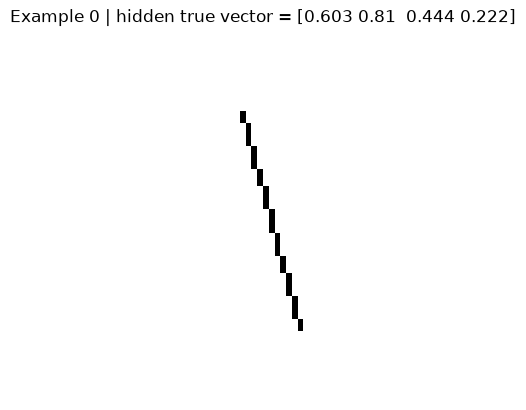

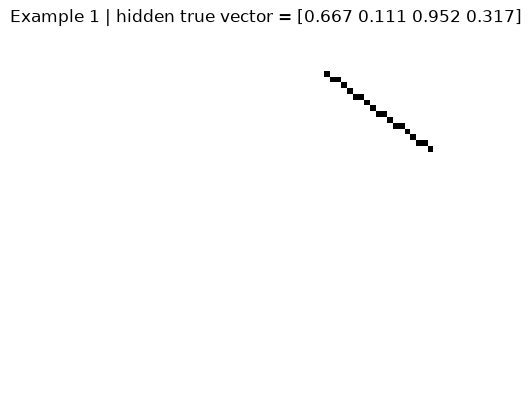

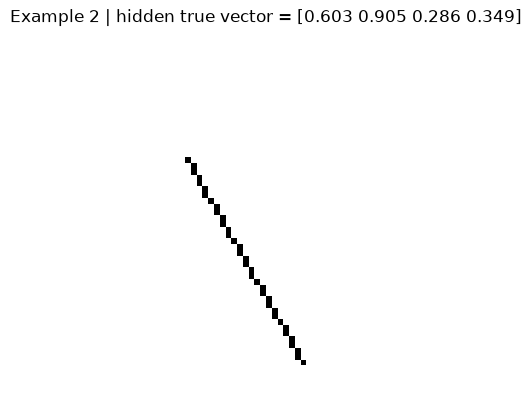

In [3]:
# ============================
# 3. Show examples
# ============================

for i in range(3):
    plt.imshow(X_train[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"Example {i} | hidden true vector = {np.round(y_train[i], 3)}")
    plt.axis("off")
    plt.show()


## 4. Soft rasteriser

This is used only to calculate a raster-image part of the reward.


In [4]:
# ============================
# 4. TensorFlow soft rasteriser
# ============================

class SoftLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.012, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)
        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, img_size, img_size))

    def call(self, vectors):
        x1 = tf.reshape(vectors[:, 0], (-1, 1, 1))
        y1 = tf.reshape(vectors[:, 1], (-1, 1, 1))
        x2 = tf.reshape(vectors[:, 2], (-1, 1, 1))
        y2 = tf.reshape(vectors[:, 3], (-1, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1
        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)
        line_darkness = tf.exp(-distance_squared / (2.0 * self.sigma * self.sigma))

        # Output image: 0 = black line, 1 = white background
        raster = 1.0 - line_darkness
        return tf.expand_dims(raster, axis=-1)


rasteriser = SoftLineRasteriser(img_size=IMG_SIZE, sigma=RASTER_SIGMA)


## 5. Reward function

This is the main improvement.

The earlier version rewarded only raster similarity. That made a dot or mostly-white image too easy.

This version rewards:

- correct vector coordinates,
- correct raster appearance,
- correct line length.

Endpoint order is handled, so `[x1, y1, x2, y2]` and `[x2, y2, x1, y1]` are treated as the same line.


In [5]:
# ============================
# 5. Reward function
# ============================

def endpoint_ordered_mse(true_vectors, predicted_vectors):
    direct = tf.reduce_mean(tf.square(true_vectors - predicted_vectors), axis=1)

    reversed_pred = tf.stack([
        predicted_vectors[:, 2],
        predicted_vectors[:, 3],
        predicted_vectors[:, 0],
        predicted_vectors[:, 1]
    ], axis=1)

    reversed_loss = tf.reduce_mean(tf.square(true_vectors - reversed_pred), axis=1)

    return tf.minimum(direct, reversed_loss)


def vector_lengths(vectors):
    dx = vectors[:, 2] - vectors[:, 0]
    dy = vectors[:, 3] - vectors[:, 1]
    return tf.sqrt(dx * dx + dy * dy + 1e-8)


def calculate_reward(target_images, true_vectors, predicted_vectors):
    # 1. Coordinate reward
    coord_mse = endpoint_ordered_mse(true_vectors, predicted_vectors)
    coord_reward = tf.exp(-60.0 * coord_mse)

    # 2. Raster reward
    predicted_images = rasteriser(predicted_vectors)

    # Line pixels are rare, so give dark line pixels a much higher weight.
    line_weight = 1.0 + 40.0 * (1.0 - target_images)

    raster_mse = tf.reduce_mean(
        line_weight * tf.square(target_images - predicted_images),
        axis=[1, 2, 3]
    )

    raster_reward = tf.exp(-80.0 * raster_mse)

    # 3. Length reward: prevents the policy from collapsing to tiny dot-like lines.
    true_length = vector_lengths(true_vectors)
    predicted_length = vector_lengths(predicted_vectors)
    length_error = tf.square(true_length - predicted_length)
    length_reward = tf.exp(-25.0 * length_error)

    reward = (
        COORD_REWARD_WEIGHT * coord_reward +
        RASTER_REWARD_WEIGHT * raster_reward +
        LENGTH_REWARD_WEIGHT * length_reward
    )

    return reward, coord_reward, raster_reward, length_reward


## 6. Actor-critic agent

The actor predicts four vector coordinates.

The model samples actions in logit-space and then applies sigmoid. This avoids the clipping problem from the previous version.


In [6]:
# ============================
# 6. Actor-critic model
# ============================

class RLVectorAgent(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.feature_extractor = models.Sequential([
            layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.Flatten(),

            layers.Dense(256, activation="relu"),
            layers.Dense(128, activation="relu"),
        ])

        # Actor: unbounded coordinate logits
        self.actor_logits = layers.Dense(4)

        # Critic: expected reward
        self.value_head = layers.Dense(1)

        # Trainable exploration noise in logit-space.
        # -2.0 gives std around 0.135.
        self.log_std = tf.Variable(
            initial_value=tf.ones((4,), dtype=tf.float32) * -2.0,
            trainable=True,
            name="log_std"
        )

    def call(self, images):
        features = self.feature_extractor(images)
        logits = self.actor_logits(features)
        values = self.value_head(features)
        mean_vectors = tf.sigmoid(logits)
        return logits, mean_vectors, values

    def sample_action(self, images):
        logits, mean_vectors, values = self(images)

        std = tf.exp(self.log_std)
        noise = tf.random.normal(shape=tf.shape(logits))
        raw_actions = logits + noise * std

        # Coordinates stay between 0 and 1 without hard clipping.
        actions = tf.sigmoid(raw_actions)

        # Log probability of the raw sampled action under a Normal distribution.
        log_probs = -0.5 * tf.square((raw_actions - logits) / (std + 1e-8))
        log_probs -= tf.math.log(std + 1e-8)
        log_probs -= 0.5 * tf.math.log(2.0 * np.pi)
        log_probs = tf.reduce_sum(log_probs, axis=1)

        entropy = tf.reduce_sum(
            0.5 * tf.math.log(2.0 * np.pi * np.e * tf.square(std))
        )

        return actions, log_probs, values, entropy


agent = RLVectorAgent()

# Build model once
dummy = tf.zeros((1, IMG_SIZE, IMG_SIZE, 1))
_ = agent(dummy)

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

print("Agent built.")
print("Initial exploration std:", tf.exp(agent.log_std).numpy())


Agent built.
Initial exploration std: [0.13533528 0.13533528 0.13533528 0.13533528]


## 7. Reinforcement-learning train step

The reward is stopped before the gradient calculation. This keeps it as policy-gradient reinforcement learning rather than supervised coordinate regression.


In [7]:
# ============================
# 7. One reinforcement-learning train step
# ============================

@tf.function
def train_step(batch_images, batch_vectors):
    with tf.GradientTape() as tape:
        actions, log_probs, values, entropy = agent.sample_action(batch_images)

        rewards, coord_rewards, raster_rewards, length_rewards = calculate_reward(
            batch_images,
            batch_vectors,
            actions
        )

        rewards_stopped = tf.stop_gradient(rewards)

        values = tf.squeeze(values, axis=1)
        advantages = rewards_stopped - values

        # Normalise advantages inside the batch for more stable policy-gradient updates.
        advantage_mean = tf.reduce_mean(advantages)
        advantage_std = tf.math.reduce_std(advantages) + 1e-8
        norm_advantages = (advantages - advantage_mean) / advantage_std

        actor_loss = -tf.reduce_mean(log_probs * tf.stop_gradient(norm_advantages))
        critic_loss = tf.reduce_mean(tf.square(rewards_stopped - values))
        entropy_loss = -ENTROPY_BONUS * entropy

        total_loss = actor_loss + VALUE_LOSS_WEIGHT * critic_loss + entropy_loss

    gradients = tape.gradient(total_loss, agent.trainable_variables)
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    optimizer.apply_gradients(zip(gradients, agent.trainable_variables))

    return (
        total_loss,
        actor_loss,
        critic_loss,
        tf.reduce_mean(rewards),
        tf.reduce_mean(coord_rewards),
        tf.reduce_mean(raster_rewards),
        tf.reduce_mean(length_rewards),
        tf.reduce_mean(values),
        tf.reduce_mean(vector_lengths(actions))
    )


In [8]:
# ============================
# 8. Train the reinforcement model
# ============================

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

rl_history = {
    "loss": [],
    "actor_loss": [],
    "critic_loss": [],
    "reward": [],
    "coord_reward": [],
    "raster_reward": [],
    "length_reward": [],
    "value": [],
    "predicted_length": []
}

for epoch in range(RL_EPOCHS):
    epoch_losses = []
    epoch_actor = []
    epoch_critic = []
    epoch_rewards = []
    epoch_coord_rewards = []
    epoch_raster_rewards = []
    epoch_length_rewards = []
    epoch_values = []
    epoch_lengths = []

    for batch_images, batch_vectors in train_dataset:
        result = train_step(batch_images, batch_vectors)
        (
            total_loss,
            actor_loss,
            critic_loss,
            mean_reward,
            mean_coord_reward,
            mean_raster_reward,
            mean_length_reward,
            mean_value,
            mean_predicted_length
        ) = result

        epoch_losses.append(float(total_loss))
        epoch_actor.append(float(actor_loss))
        epoch_critic.append(float(critic_loss))
        epoch_rewards.append(float(mean_reward))
        epoch_coord_rewards.append(float(mean_coord_reward))
        epoch_raster_rewards.append(float(mean_raster_reward))
        epoch_length_rewards.append(float(mean_length_reward))
        epoch_values.append(float(mean_value))
        epoch_lengths.append(float(mean_predicted_length))

    rl_history["loss"].append(np.mean(epoch_losses))
    rl_history["actor_loss"].append(np.mean(epoch_actor))
    rl_history["critic_loss"].append(np.mean(epoch_critic))
    rl_history["reward"].append(np.mean(epoch_rewards))
    rl_history["coord_reward"].append(np.mean(epoch_coord_rewards))
    rl_history["raster_reward"].append(np.mean(epoch_raster_rewards))
    rl_history["length_reward"].append(np.mean(epoch_length_rewards))
    rl_history["value"].append(np.mean(epoch_values))
    rl_history["predicted_length"].append(np.mean(epoch_lengths))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:03d}/{RL_EPOCHS} | "
            f"reward={rl_history['reward'][-1]:.4f} | "
            f"coord={rl_history['coord_reward'][-1]:.4f} | "
            f"raster={rl_history['raster_reward'][-1]:.4f} | "
            f"length={rl_history['length_reward'][-1]:.4f} | "
            f"pred_len={rl_history['predicted_length'][-1]:.3f}"
        )


Epoch 001/120 | reward=0.0391 | coord=0.0429 | raster=0.0000 | length=0.0906 | pred_len=0.075
Epoch 005/120 | reward=0.0450 | coord=0.0482 | raster=0.0000 | length=0.1123 | pred_len=0.093
Epoch 010/120 | reward=0.0412 | coord=0.0449 | raster=0.0000 | length=0.0974 | pred_len=0.075
Epoch 015/120 | reward=0.0406 | coord=0.0447 | raster=0.0000 | length=0.0929 | pred_len=0.071
Epoch 020/120 | reward=0.0402 | coord=0.0444 | raster=0.0000 | length=0.0913 | pred_len=0.069
Epoch 025/120 | reward=0.0404 | coord=0.0445 | raster=0.0000 | length=0.0924 | pred_len=0.069
Epoch 030/120 | reward=0.0397 | coord=0.0442 | raster=0.0000 | length=0.0880 | pred_len=0.067
Epoch 035/120 | reward=0.0402 | coord=0.0449 | raster=0.0000 | length=0.0878 | pred_len=0.067
Epoch 040/120 | reward=0.0395 | coord=0.0440 | raster=0.0000 | length=0.0872 | pred_len=0.067
Epoch 045/120 | reward=0.0391 | coord=0.0433 | raster=0.0000 | length=0.0876 | pred_len=0.066
Epoch 050/120 | reward=0.0393 | coord=0.0435 | raster=0.0000

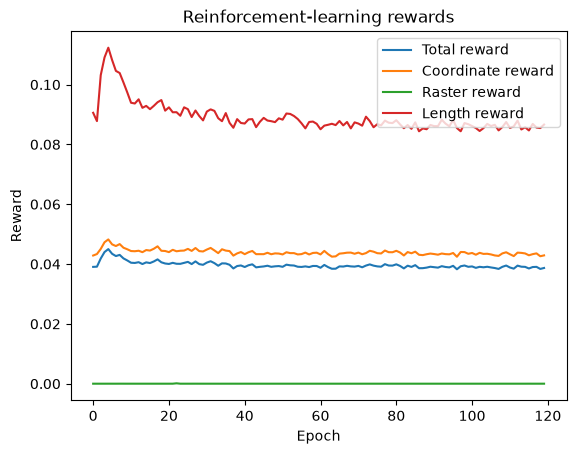

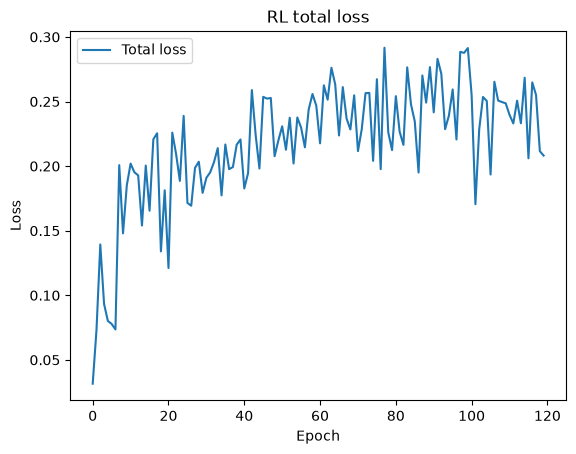

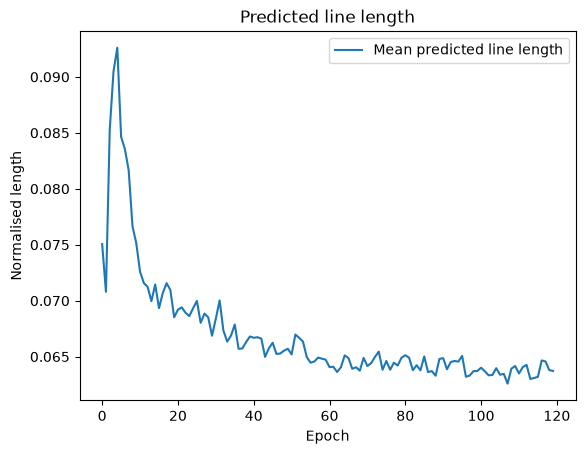

In [9]:
# ============================
# 9. Plot RL training curves
# ============================

plt.plot(rl_history["reward"], label="Total reward")
plt.plot(rl_history["coord_reward"], label="Coordinate reward")
plt.plot(rl_history["raster_reward"], label="Raster reward")
plt.plot(rl_history["length_reward"], label="Length reward")
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.title("Reinforcement-learning rewards")
plt.legend()
plt.show()

plt.plot(rl_history["loss"], label="Total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RL total loss")
plt.legend()
plt.show()

plt.plot(rl_history["predicted_length"], label="Mean predicted line length")
plt.xlabel("Epoch")
plt.ylabel("Normalised length")
plt.title("Predicted line length")
plt.legend()
plt.show()


In [10]:
# ============================
# 10. Helper functions for display
# ============================

def hard_rasterise_line(vector):
    x1, y1, x2, y2 = (vector * (IMG_SIZE - 1)).astype(int)

    image = Image.new("L", (IMG_SIZE, IMG_SIZE), color=255)
    draw = ImageDraw.Draw(image)
    draw.line((x1, y1, x2, y2), fill=0, width=1)

    return np.array(image).astype("float32") / 255.0


def predict_mean_vector(image):
    image_batch = image[None, ...].astype("float32")
    logits, mean_vectors, values = agent(image_batch)
    return mean_vectors.numpy()[0], values.numpy()[0, 0]


def display_prediction(index=0):
    image = X_test[index]
    true_vector = y_test[index]

    predicted_vector, predicted_value = predict_mean_vector(image)

    predicted_soft = rasteriser(tf.constant(predicted_vector[None, :], dtype=tf.float32)).numpy()[0]
    predicted_hard = hard_rasterise_line(predicted_vector)

    rewards = calculate_reward(
        tf.constant(image[None, ...], dtype=tf.float32),
        tf.constant(true_vector[None, :], dtype=tf.float32),
        tf.constant(predicted_vector[None, :], dtype=tf.float32)
    )

    reward, coord_reward, raster_reward, length_reward = [float(x.numpy()[0]) for x in rewards]

    print("True vector:      ", np.round(true_vector, 3))
    print("Predicted vector: ", np.round(predicted_vector, 3))
    print("True pixels:      ", (true_vector * (IMG_SIZE - 1)).astype(int))
    print("Predicted pixels: ", (predicted_vector * (IMG_SIZE - 1)).astype(int))
    print("Total reward:     ", round(reward, 4))
    print("Coordinate reward:", round(coord_reward, 4))
    print("Raster reward:    ", round(raster_reward, 4))
    print("Length reward:    ", round(length_reward, 4))
    print("Critic value:     ", round(float(predicted_value), 4))

    plt.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Input raster")
    plt.axis("off")
    plt.show()

    plt.imshow(predicted_soft.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Soft rasterised policy output")
    plt.axis("off")
    plt.show()

    plt.imshow(predicted_hard, cmap="gray", vmin=0, vmax=1)
    plt.title("Hard rasterised vector output")
    plt.axis("off")
    plt.show()


True vector:       [0.714 0.159 0.206 0.317]
Predicted vector:  [0.491 0.5   0.501 0.497]
True pixels:       [45 10 13 20]
Predicted pixels:  [30 31 31 31]
Total reward:      0.0115
Coordinate reward: 0.0162
Raster reward:     0.0
Length reward:     0.0011
Critic value:      0.0181


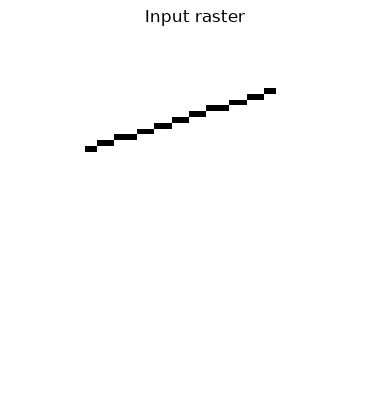

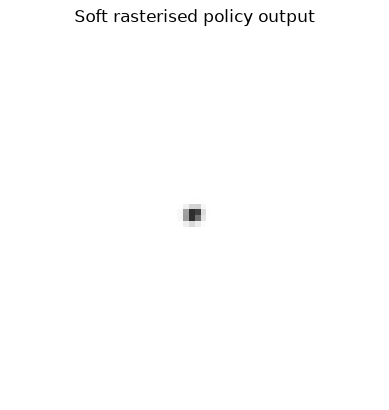

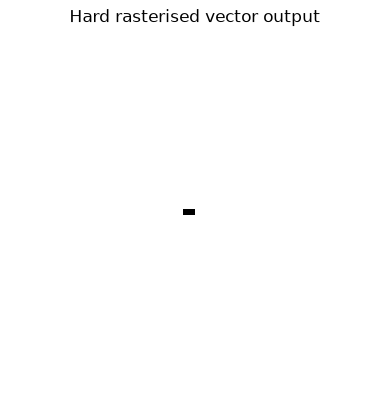

True vector:       [0.984 0.111 0.032 0.429]
Predicted vector:  [0.484 0.498 0.507 0.495]
True pixels:       [62  7  2 27]
Predicted pixels:  [30 31 31 31]
Total reward:      0.0001
Coordinate reward: 0.0002
Raster reward:     0.0
Length reward:     0.0
Critic value:      -0.0043


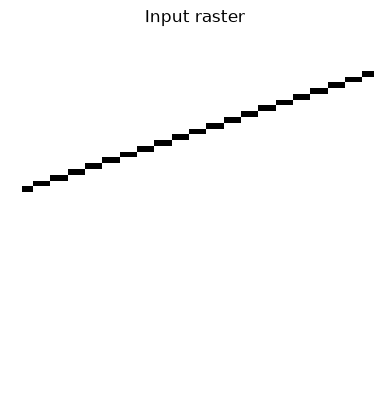

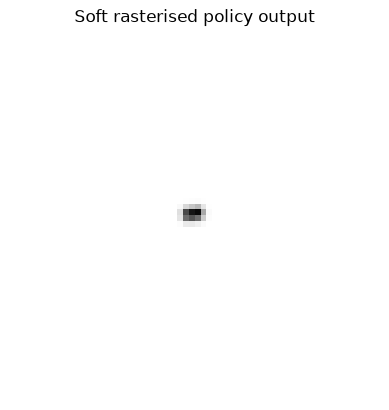

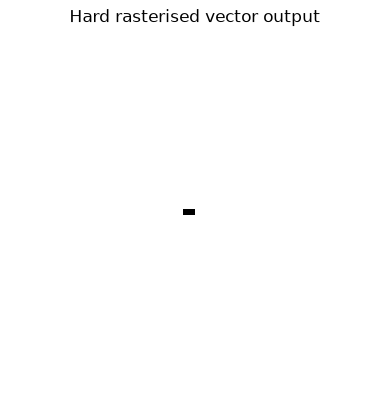

True vector:       [0.952 0.444 0.349 0.27 ]
Predicted vector:  [0.486 0.502 0.497 0.495]
True pixels:       [60 28 22 17]
Predicted pixels:  [30 31 31 31]
Total reward:      0.0101
Coordinate reward: 0.0145
Raster reward:     0.0
Length reward:     0.0001
Critic value:      0.0154


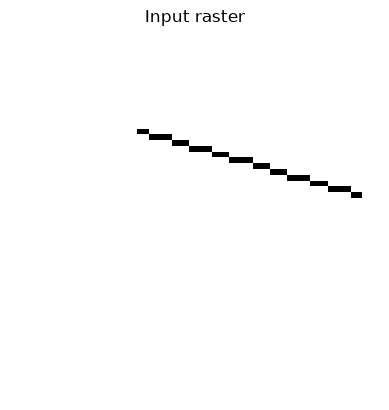

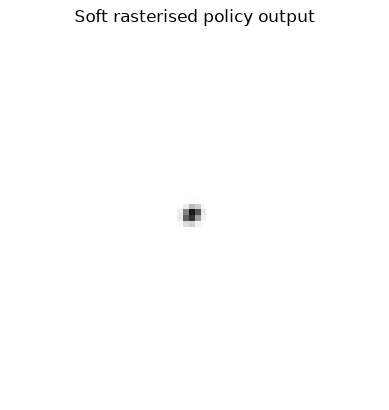

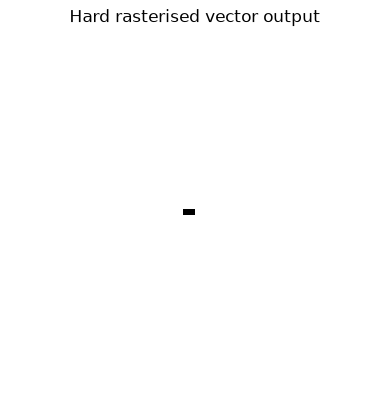

In [11]:
# ============================
# 11. Test predictions
# ============================

display_prediction(0)
display_prediction(1)
display_prediction(2)


In [12]:
# ============================
# 12. Test-set reward and coordinate error
# ============================

test_images = tf.constant(X_test, dtype=tf.float32)
test_vectors = tf.constant(y_test, dtype=tf.float32)

_, mean_vectors, value_predictions = agent(test_images)
rewards, coord_rewards, raster_rewards, length_rewards = calculate_reward(
    test_images,
    test_vectors,
    mean_vectors
)

coord_mse = endpoint_ordered_mse(test_vectors, mean_vectors)
coord_mae = tf.reduce_mean(tf.abs(test_vectors - mean_vectors), axis=1)

print("Mean test reward:       ", float(tf.reduce_mean(rewards)))
print("Mean coordinate reward: ", float(tf.reduce_mean(coord_rewards)))
print("Mean raster reward:     ", float(tf.reduce_mean(raster_rewards)))
print("Mean length reward:     ", float(tf.reduce_mean(length_rewards)))
print("Mean coordinate MSE:    ", float(tf.reduce_mean(coord_mse)))
print("Mean coordinate MAE:    ", float(tf.reduce_mean(coord_mae)))
print("Current exploration std:", tf.exp(agent.log_std).numpy())


Mean test reward:        0.03492185100913048
Mean coordinate reward:  0.041582800447940826
Mean raster reward:      5.495440746017266e-06
Mean length reward:      0.05812789127230644
Mean coordinate MSE:     0.0854099839925766
Mean coordinate MAE:     0.2575279772281647
Current exploration std: [0.13533528 0.13533528 0.13533528 0.13533528]


In [13]:
# ============================
# 13. Export one predicted vector as SVG
# ============================

def vector_to_svg(vector, width=64, height=64):
    x1, y1, x2, y2 = (vector * (IMG_SIZE - 1)).astype(int)

    svg = (
        f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg">\n'
        f'    <line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
        f'stroke="black" stroke-width="1"/>\n'
        f'</svg>'
    )

    return svg


sample_index = 0
predicted_vector, _ = predict_mean_vector(X_test[sample_index])

svg_output = vector_to_svg(predicted_vector)
print(svg_output)


<svg width="64" height="64" xmlns="http://www.w3.org/2000/svg">
    <line x1="30" y1="31" x2="31" y2="31" stroke="black" stroke-width="1"/>
</svg>


## Notes

This is still expected to be less stable than the supervised CNN or differentiable-raster backpropagation version.

However, it is a fairer reinforcement-learning comparison than the first RL version because the reward is no longer dominated by white background pixels and dot-like predictions are penalised.

If it is still unstable, try these settings near the top:

```python
RL_EPOCHS = 200
ENTROPY_BONUS = 0.001
COORD_REWARD_WEIGHT = 0.80
RASTER_REWARD_WEIGHT = 0.10
LENGTH_REWARD_WEIGHT = 0.10
```
